In [1]:
using Pkg; Pkg.add(["ITensors", "ITensorMPS", "Plots", "LsqFit", "Statistics", "LinearAlgebra", "ProgressMeter", "LaTeXStrings", "SavitzkyGolay"])
using ITensors, ITensorMPS, Plots, LsqFit, Statistics, LinearAlgebra, ProgressMeter, LaTeXStrings, SavitzkyGolay

include("../../data/params.jl")
include("../../data/helpers/saving.jl")
include("../schmidt_spectra/get_spectrum.jl")
include("../schmidt_spectra/deviation/deviation.jl")

sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
)

   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`
   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`


Dict{String, Any} with 6 entries:
  "Δ"            => -1.0
  "J"            => -1.0
  "μ"            => 1.0
  "MAX_BOND_DIM" => 1000
  "NUM_SWEEPS"   => 10
  "ACC"          => 1.0e-16

## Bounding Error

So we define our disordered state in terms of the clean and residual states
$$
\ket{\psi_{\sigma}} = \xi \ket{\psi_{0}} + \sqrt{ 1-\xi^{2} }\ket{\psi_{r}} 
$$
We can extract residual state use Gram-Schmidt orthogonalisation:
$$
\ket{\psi_{r}} = \ket{\psi_{\sigma}} - \xi \ket{\psi_{0}}   
$$
which is no longer normalised, but can be if required by $\frac{1}{\sqrt{ 1-\xi^{2} }}$.

For simplicity, we will say $\beta=\sqrt{1-\xi^2}$.

In [3]:
function get_residual_state(ψ_σ::MPS, ψ_0::MPS; normalize::Bool = true)
    ξ = inner(ψ_σ, ψ_0)
    ψ_r = ψ_σ - ξ * ψ_0
    if normalize normalize!(ψ_r) end
    return ψ_r
end

get_residual_state (generic function with 1 method)

In [2]:
function fetch_states(
    N::Int, σ::Float64, system_params::Dict{String, Any};
    max::Union{Nothing, Int}=nothing, type::Symbol=:latest
)::Tuple{Vector{MPS}, Vector{MPS}}
    CURRENT_DIR = @__DIR__
    FP = extract_filename_from_system_params(system_params)
    MPS_FP = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(σ)_$(FP).hd5")
    matches_cln = find_runs_by_params(MPS_FP, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=type)
    matches_dis = find_runs_by_params(MPS_FP, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=type)

    cln_mpss = MPS[]
    dis_mpss = MPS[]

    for (cln, dis) in zip(matches_cln, matches_dis)
        if (cln.psi === nothing || dis.psi === nothing)
            continue
        end

        push!(cln_mpss, cln.psi)
        push!(dis_mpss, dis.psi)

        if max !== nothing && length(cln_mpss) >= max
            break
        end
    end

    return cln_mpss, dis_mpss
end

fetch_states (generic function with 1 method)

### Beta scaling with disorder

It is useful to know how $\beta=\sqrt{1-\xi^2}$ scales with $\sigma$. 

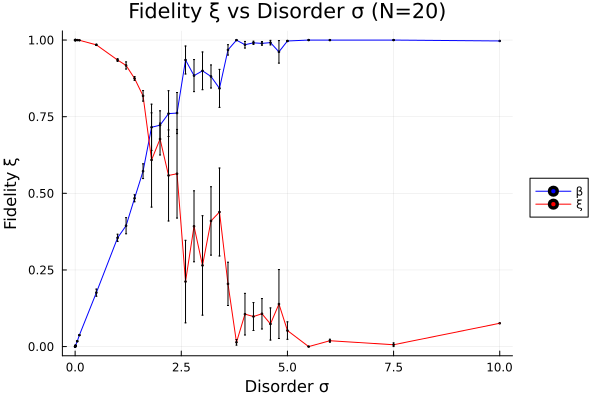

In [12]:
N = 20
sigmas = sort(vcat([0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0], 1.2:0.2:5.0, [5.5, 6.0, 7.5, 10.0]))
sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 5000, "ACC" => 10^-16
)

get_β(ψ0, ψσ) = sqrt(1 - abs(inner(ψ0, ψσ))^2)
get_ξ(ψ0, ψσ) = abs(inner(ψ0, ψσ))

βs = Float64[]
ξs = Float64[]
β_errs = Float64[]
ξ_errs = Float64[]
valid_σs = Float64[]

for σ in sigmas
    ψ0s, ψσs = fetch_states(N, σ, sysparams; type=:all)
    if !isempty(ψ0s) && !isempty(ψσs)
        loc_ξs = [get_ξ(p0, ps) for (p0, ps) in zip(ψ0s, ψσs)]
        loc_βs = [get_β(p0, ps) for (p0, ps) in zip(ψ0s, ψσs)]
        push!(βs, mean(loc_βs))
        push!(β_errs, std(loc_βs) / sqrt(length(loc_βs)))
        push!(ξs, mean(loc_ξs))
        push!(ξ_errs, std(loc_ξs) / sqrt(length(loc_ξs)))
        push!(valid_σs, σ)
    end
end

p1 = plot(
             title="Fidelity ξ vs Disorder σ (N=$N)",
             xlabel="Disorder σ", ylabel="Fidelity ξ",
             legend=:outerright, grid=true, marker=:diamond, markersize=3)
plot!(p1, valid_σs, βs, yerr=β_errs, label="β", color=:blue, marker=:circle, markersize=1)
plot!(p1, valid_σs, ξs, yerr=ξ_errs, label="ξ", color=:red, marker=:circle, markersize=1)

# sq_sum = [β^2 + ξ^2 for (β, ξ) in zip(βs, ξs)]
# plot!(p1, valid_σs, sq_sum, label="β^2+ξ^2", color=:black, alpha=0.8)

display(p1)

This looks like a phase transition.

At low $\sigma$, the fidelity is near 1. This matches the idea that that the ground state is near identical to the clean state, which is of course what we should expect given the physical amount of disorder is very small.

As we get to about $\sigma=2.5$, we start to lose fidelity quickly. This very much suggests that at sufficient levels of disorder, the disordered part of the spectrum becomes too strong and overpowers the clean state, becoming the dominant component in the ground state. We get large error bars here, even with quite a few runs, suggesting that the state is very dependent on the specific disorder realisation in each particular instance.

As we go larger and larger, the disorder essentially becomes the full state.

σ=5.0e-7 100%|███████████████████████████████████████████| Time: 0:01:50
σ=7.0e-7 100%|███████████████████████████████████████████| Time: 0:01:50
σ=9.0e-7 100%|███████████████████████████████████████████| Time: 0:01:59


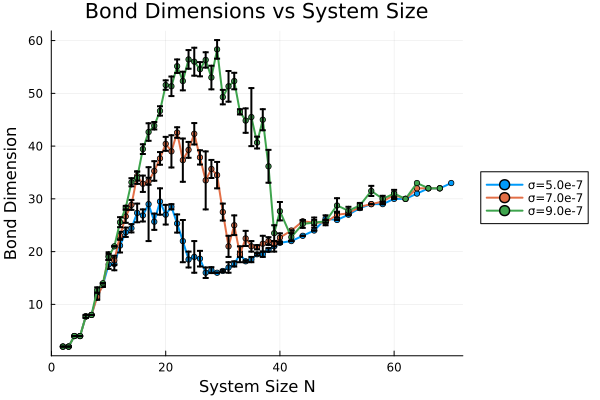

In [ ]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 25,
                    "MAX_BOND_DIM" => 2000,
                    "ACC" => 1e-16
                )

Ns = 2:1:80
σs = [5e-7, 7e-7, 9e-7]

p3 = plot(
             title="Bond Dimensions vs System Size",
             xlabel="System Size N", ylabel="Bond Dimension",
             legend=:outerright, grid=true)

for (idx, σ) in enumerate(σs)
    bond_dims = Float64[]
    errs = Float64[]
    valid_Ns = Float64[]

    prog = Progress(length(Ns); desc="σ=$σ")

    for N in Ns
        ψ0s, ψσs = fetch_states(N, σ, system_params; type=:all)
        if !isempty(ψ0s) && !isempty(ψσs)
            bond_ds = [maxlinkdim(ps) for ps in ψσs]
            push!(bond_dims, mean(bond_ds))
            push!(errs, std(bond_ds) / sqrt(length(bond_ds)))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    # Plot this sigma's data
    if !isempty(valid_Ns)
        plot!(p3, valid_Ns, bond_dims, yerr=errs,
              label="σ=$σ",
              color=idx,
              marker=:circle,
              markersize=3,
              linewidth=2)
    end
end

display(p3)

σ=5.0e-7 100%|███████████████████████████████████████████| Time: 0:06:00
σ=7.0e-7 100%|███████████████████████████████████████████| Time: 0:06:10
σ=9.0e-7 100%|███████████████████████████████████████████| Time: 0:05:54
σ=5.0e-6 100%|███████████████████████████████████████████| Time: 0:00:21


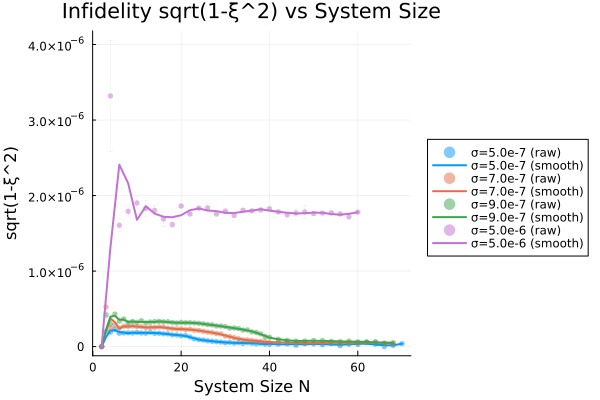

In [7]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 25,
                    "MAX_BOND_DIM" => 2000,
                    "ACC" => 1e-16
                )

Ns = 2:1:80
σs = [5e-7, 7e-7, 9e-7, 5e-6]

get_β(ψ0, ψσ) = sqrt(1 - min(1, abs(inner(ψ0, ψσ))^2))

p2 = plot(
    title="Infidelity sqrt(1-ξ^2) vs System Size",
    xlabel="System Size N",
    ylabel="sqrt(1-ξ^2)",
    legend=:outerright,
    grid=true
)

for (idx, σ) in enumerate(σs)
    βs = Float64[]
    β_errs = Float64[]
    valid_Ns = Float64[]

    prog = Progress(length(Ns); desc="σ=$σ")

    for N in Ns
        ψ0s, ψσs = fetch_states(N, σ, system_params; type=:all)
        if !isempty(ψ0s) && !isempty(ψσs)
            loc_βs = [get_β(p0, ps) for (p0, ps) in zip(ψ0s, ψσs)]
            push!(βs, mean(loc_βs))
            push!(β_errs, std(loc_βs) / sqrt(length(loc_βs)))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    if !isempty(valid_Ns)
        scatter!(p2, valid_Ns, βs, yerr=β_errs,
                 label="σ=$σ (raw)",
                 color=idx,
                 markersize=3,
                 markerstrokewidth=0,
                 alpha=0.5)

        if length(βs) >= 7
            smoothed_result = savitzky_golay(βs, 7, 2)
            βs_smooth = smoothed_result.y

            plot!(p2, valid_Ns, βs_smooth,
                  label="σ=$σ (smooth)",
                  color=idx,
                  linewidth=2)
        elseif length(βs) >= 3
            smoothed_result = savitzky_golay(βs, 3, 1)
            plot!(p2, valid_Ns, smoothed_result.y,
                  label="σ=$σ (smooth)",
                  color=idx,
                  linewidth=2)
        end
    end
end

display(p2)

I think this can be explained by the following logic:
- for small $N$, the system is not large enough to tone out the disorder. Even though the disorder is relativity small, the error (infidelity) that it produces is on roughly the same order as itself, although this may be a coincidence. 
- as the systems get larger, the indfidelity tends roughly to zero. This suggests that the system is self averaging - this level of disorder has less effect for smaller systems, which we can take as a sort of mean-field idea (and this 'average' field is tending to some constant, which is just that of the clean state). 

σ=5.0e-7 100%|███████████████████████████████████████████| Time: 0:00:17
σ=7.0e-7 100%|███████████████████████████████████████████| Time: 0:00:17
σ=9.0e-7 100%|███████████████████████████████████████████| Time: 0:00:17
σ=1.0e-6 100%|███████████████████████████████████████████| Time: 0:00:18
σ=1.25e-6 100%|██████████████████████████████████████████| Time: 0:00:09
σ=1.5e-6 100%|███████████████████████████████████████████| Time: 0:00:03
σ=1.75e-6 100%|██████████████████████████████████████████| Time: 0:00:03
σ=2.0e-6 100%|███████████████████████████████████████████| Time: 0:00:03
σ=2.25e-6 100%|██████████████████████████████████████████| Time: 0:00:08
σ=2.5e-6 100%|███████████████████████████████████████████| Time: 0:00:02
σ=2.75e-6 100%|██████████████████████████████████████████| Time: 0:00:02
σ=3.0e-6 100%|███████████████████████████████████████████| Time: 0:00:04
σ=3.25e-6 100%|██████████████████████████████████████████| Time: 0:00:11
σ=3.5e-6 100%|█████████████████████████████████████

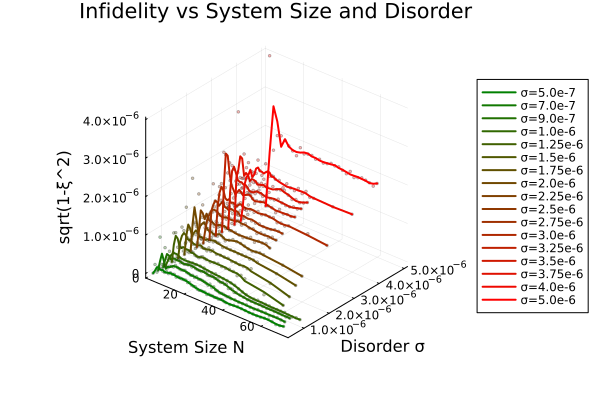

In [ ]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 25,
                    "MAX_BOND_DIM" => 2000,
                    "ACC" => 1e-16
                )

Ns = 2:1:80
σs = [5e-7, 7e-7, 9e-7, 1e-6, 1.5e-6, 2e-6, 2.5e-6, 3e-6, 3.5e-6, 4e-6, 5e-6]

get_β(ψ0, ψσ) = sqrt(max(0.0, 1.0 - min(1.0, abs(inner(ψ0, ψσ))^2)))

p3d = plot(
    title="Infidelity vs System Size and Disorder",
    xlabel="System Size N",
    ylabel="Disorder σ",
    zlabel="sqrt(1-ξ^2)",
    camera=(40, 30),
    legend=:outerright,
    grid=true
)

grad = cgrad([:green, :red])

for (idx, σ) in enumerate(σs)
    βs = Float64[]
    valid_Ns = Float64[]

    prog = Progress(length(Ns); desc="σ=$σ")

    for N in Ns
        ψ0s, ψσs = fetch_states(N, σ, system_params; type=:latest)
        if !isempty(ψ0s) && !isempty(ψσs)
            loc_βs = [get_β(p0, ps) for (p0, ps) in zip(ψ0s, ψσs)]
            push!(βs, mean(loc_βs))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    line_color = grad[(idx-1)/(max(1, length(σs)-1))]

    if !isempty(valid_Ns)
        if length(βs) >= 7
            βs_smooth = savitzky_golay(βs, 7, 2).y
        elseif length(βs) >= 3
            βs_smooth = savitzky_golay(βs, 3, 1).y
        else
            βs_smooth = βs
        end

        scatter!(p3d, valid_Ns, fill(σ, length(valid_Ns)), βs,
                 label=false,
                 color=line_color,
                 markersize=1.5,
                 alpha=0.3)

        plot!(p3d, valid_Ns, fill(σ, length(valid_Ns)), βs_smooth,
              label="σ=$σ",
              color=line_color,
              linewidth=2)
    end
end

display(p3d)

acc=1.0e-10 100%|████████████████████████████████████████| Time: 0:00:46
acc=1.0e-12 100%|████████████████████████████████████████| Time: 0:00:46
acc=1.0e-14 100%|████████████████████████████████████████| Time: 0:00:44
acc=1.0e-16 100%|████████████████████████████████████████| Time: 0:00:59


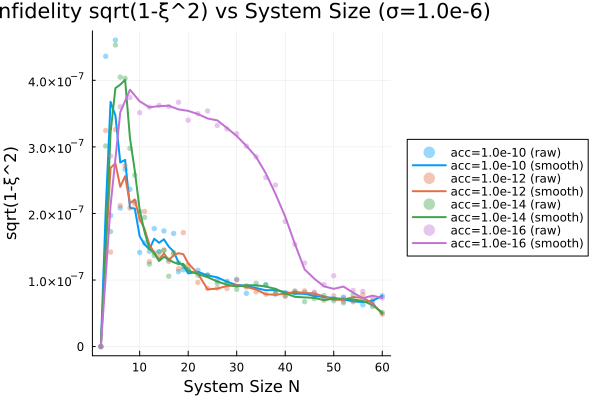

In [5]:
Ns = 2:1:60
σ = 1e-6
accuracies = [1e-10, 1e-12, 1e-14, 1e-16]

# Robust beta calculation to prevent DomainErrors
get_β(ψ0, ψσ) = sqrt(max(0.0, 1.0 - min(1.0, abs(inner(ψ0, ψσ))^2)))

p2 = plot(
    title="Infidelity sqrt(1-ξ^2) vs System Size (σ=$σ)",
    xlabel="System Size N",
    ylabel="sqrt(1-ξ^2)",
    legend=:outerright,
    grid=true
)

for (idx, acc) in enumerate(accuracies)
    βs = Float64[]
    β_errs = Float64[]
    valid_Ns = Float64[]

    system_params = Dict{String,Any}(
        "J" => -1.0,
        "Δ" => -1.0,
        "μ" => 1.0,
        "NUM_SWEEPS" => 25,
        "MAX_BOND_DIM" => 2000,
        "ACC" => acc
    )

    prog = Progress(length(Ns); desc="acc=$acc")

    for N in Ns
        ψ0s, ψσs = fetch_states(N, σ, system_params; type=:all)
        if !isempty(ψ0s) && !isempty(ψσs)
            loc_βs = [get_β(p0, ps) for (p0, ps) in zip(ψ0s, ψσs)]
            push!(βs, mean(loc_βs))
            push!(β_errs, std(loc_βs) / sqrt(length(loc_βs)))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    if !isempty(valid_Ns)
        scatter!(p2, valid_Ns, βs,
                 label="acc=$acc (raw)",
                 color=idx,
                 markersize=3,
                 markerstrokewidth=0,
                 alpha=0.4)

        if length(βs) >= 7
            res = savitzky_golay(βs, 7, 2)
            βs_smooth = res.y

            plot!(p2, valid_Ns, βs_smooth,
                  label="acc=$acc (smooth)",
                  color=idx,
                  linewidth=2)
        elseif length(βs) >= 3

            res = savitzky_golay(βs, 3, 1)
            plot!(p2, valid_Ns, res.y,
                  label="acc=$acc (smooth)",
                  color=idx,
                  linewidth=2)
        end
    end
end

display(p2)

acc=1.0e-16 100%|████████████████████████████████████████| Time: 0:00:49
acc=2.5e-16 100%|████████████████████████████████████████| Time: 0:00:09
acc=5.0e-16 100%|████████████████████████████████████████| Time: 0:00:09
acc=7.5e-16 100%|████████████████████████████████████████| Time: 0:00:09
acc=1.0e-15 100%|████████████████████████████████████████| Time: 0:00:17
acc=2.0e-15 100%|████████████████████████████████████████| Time: 0:00:17
acc=5.0e-15 100%|████████████████████████████████████████| Time: 0:00:16


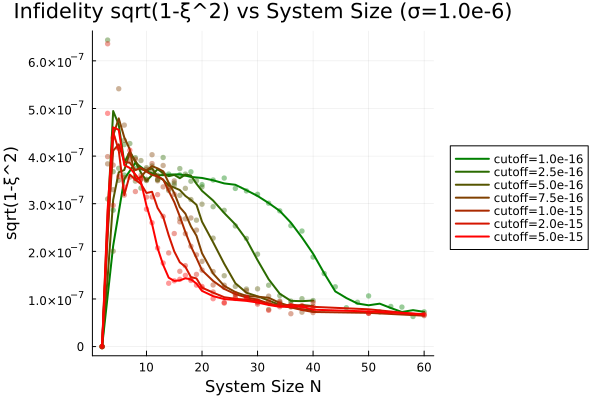

In [20]:
Ns = 2:1:60
σ = 1e-6
accuracies = [1e-16, 0.25e-15, 0.5e-15, 0.75e-15, 1e-15, 2e-15, 5e-15]

# Robust beta calculation to prevent DomainErrors
get_β(ψ0, ψσ) = sqrt(max(0.0, 1.0 - min(1.0, abs(inner(ψ0, ψσ))^2)))

p2 = plot(
    title="Infidelity sqrt(1-ξ^2) vs System Size (σ=$σ)",
    xlabel="System Size N",
    ylabel="sqrt(1-ξ^2)",
    legend=:outerright,
    grid=true
)

grad = cgrad([:green, :red])

for (idx, acc) in enumerate(accuracies)
    βs = Float64[]
    β_errs = Float64[]
    valid_Ns = Float64[]

    system_params = Dict{String,Any}(
        "J" => -1.0,
        "Δ" => -1.0,
        "μ" => 1.0,
        "NUM_SWEEPS" => 25,
        "MAX_BOND_DIM" => 2000,
        "ACC" => acc
    )

    prog = Progress(length(Ns); desc="acc=$acc")

    for N in Ns
        ψ0s, ψσs = fetch_states(N, σ, system_params; type=:all)
        if !isempty(ψ0s) && !isempty(ψσs)
            loc_βs = [get_β(p0, ps) for (p0, ps) in zip(ψ0s, ψσs)]
            push!(βs, mean(loc_βs))
            push!(β_errs, std(loc_βs) / sqrt(length(loc_βs)))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    line_color = grad[(idx-1)/(length(accuracies)-1)]

    if !isempty(valid_Ns)
        scatter!(p2, valid_Ns, βs,
                 label=false,
                 color=line_color,
                 markersize=3,
                 markerstrokewidth=0,
                 alpha=0.4)

        if length(βs) >= 7
            res = savitzky_golay(βs, 7, 2)
            βs_smooth = res.y

            plot!(p2, valid_Ns, βs_smooth,
                  label="cutoff=$acc",
                  color=line_color,
                  linewidth=2)
        elseif length(βs) >= 3

            res = savitzky_golay(βs, 3, 1)
            plot!(p2, valid_Ns, res.y,
                  label="acc=$acc",
                  color=line_color,
                  linewidth=2)
        end
    end
end

display(p2)

acc=1.0e-10 100%|████████████████████████████████████████| Time: 0:00:12
acc=1.0e-12 100%|████████████████████████████████████████| Time: 0:00:12
acc=1.0e-14 100%|████████████████████████████████████████| Time: 0:00:12
acc=1.0e-16 100%|████████████████████████████████████████| Time: 0:04:13


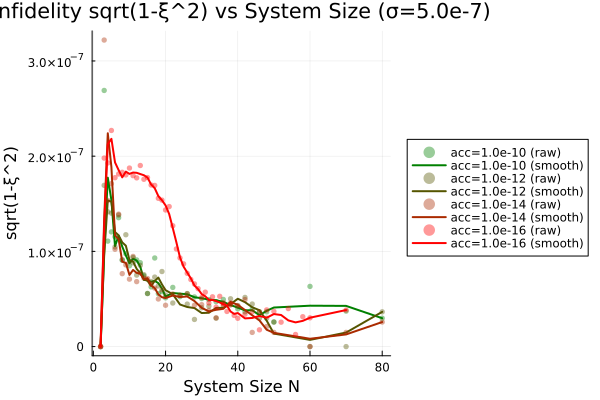

In [21]:
Ns = vcat(2:1:60, [70, 80, 90, 100])
σ = 5e-7
accuracies = [1e-10, 1e-12, 1e-14, 1e-16]

# Robust beta calculation to prevent DomainErrors
get_β(ψ0, ψσ) = sqrt(max(0.0, 1.0 - min(1.0, abs(inner(ψ0, ψσ))^2)))

p2 = plot(
    title="Infidelity sqrt(1-ξ^2) vs System Size (σ=$σ)",
    xlabel="System Size N",
    ylabel="sqrt(1-ξ^2)",
    legend=:outerright,
    grid=true
)

for (idx, acc) in enumerate(accuracies)
    βs = Float64[]
    β_errs = Float64[]
    valid_Ns = Float64[]

    system_params = Dict{String,Any}(
        "J" => -1.0,
        "Δ" => -1.0,
        "μ" => 1.0,
        "NUM_SWEEPS" => 25,
        "MAX_BOND_DIM" => 2000,
        "ACC" => acc
    )

    prog = Progress(length(Ns); desc="acc=$acc")

    for N in Ns
        ψ0s, ψσs = fetch_states(N, σ, system_params; type=:all)
        if !isempty(ψ0s) && !isempty(ψσs)
            loc_βs = [get_β(p0, ps) for (p0, ps) in zip(ψ0s, ψσs)]
            push!(βs, mean(loc_βs))
            push!(β_errs, std(loc_βs) / sqrt(length(loc_βs)))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    line_color = grad[(idx-1)/(length(accuracies)-1)]

    if !isempty(valid_Ns)
        scatter!(p2, valid_Ns, βs,
                 label="acc=$acc (raw)",
                 color=line_color,
                 markersize=3,
                 markerstrokewidth=0,
                 alpha=0.4)

        if length(βs) >= 7
            res = savitzky_golay(βs, 7, 2)
            βs_smooth = res.y

            plot!(p2, valid_Ns, βs_smooth,
                  label="acc=$acc (smooth)",
                  color=line_color,
                  linewidth=2)
        elseif length(βs) >= 3

            res = savitzky_golay(βs, 3, 1)
            plot!(p2, valid_Ns, res.y,
                  label="acc=$acc (smooth)",
                  color=line_color,
                  linewidth=2)
        end
    end
end

display(p2)

acc=1.0e-16 100%|████████████████████████████████████████| Time: 0:00:54
acc=2.5e-16 100%|████████████████████████████████████████| Time: 0:00:10
acc=5.0e-16 100%|████████████████████████████████████████| Time: 0:00:11
acc=7.5e-16 100%|████████████████████████████████████████| Time: 0:00:10
acc=1.0e-15 100%|████████████████████████████████████████| Time: 0:00:20
acc=2.0e-15 100%|████████████████████████████████████████| Time: 0:00:20
acc=5.0e-15 100%|████████████████████████████████████████| Time: 0:00:19
acc=1.0e-14 100%|████████████████████████████████████████| Time: 0:00:54


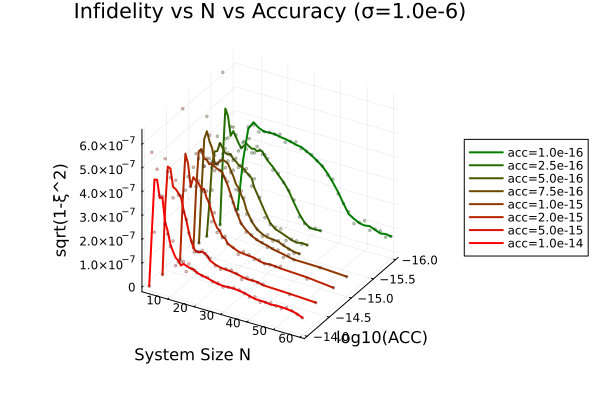

In [ ]:


# Parameters
Ns = 2:1:60
σ = 1e-6
accuracies = [1e-16, 0.25e-15, 0.5e-15, 0.75e-15, 1e-15, 2e-15, 5e-15, 1e-14]
acc_logs = log10.(accuracies)

get_β(ψ0, ψσ) = sqrt(max(0.0, 1.0 - min(1.0, abs(inner(ψ0, ψσ))^2)))

# Initialize 3D Plot
p3d = plot(
    title="Infidelity vs N vs Accuracy (σ=$σ)",
    xlabel="System Size N",
    ylabel="log10(ACC)",
    zlabel="sqrt(1-ξ^2)",
    camera=(30, 30),
    legend=:outerright,
    grid=true,
    yflip=true
)

grad = cgrad([:green, :red])

for (idx, acc) in enumerate(accuracies)
    βs = Float64[]
    valid_Ns = Float64[]

    system_params = Dict{String,Any}(
        "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
        "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => acc
    )

    prog = Progress(length(Ns); desc="acc=$acc")

    for N in Ns
        ψ0s, ψσs = fetch_states(N, σ, system_params; type=:all)
        if !isempty(ψ0s) && !isempty(ψσs)
            loc_βs = [get_β(p0, ps) for (p0, ps) in zip(ψ0s, ψσs)]
            push!(βs, mean(loc_βs))
            push!(valid_Ns, N)
        end
        next!(prog)
    end

    line_color = grad[(idx-1)/(length(accuracies)-1)]
    y_val = acc_logs[idx]

    if !isempty(valid_Ns)
        if length(βs) >= 7
            βs_plot = savitzky_golay(βs, 7, 2).y
        elseif length(βs) >= 3
            βs_plot = savitzky_golay(βs, 3, 1).y
        else
            βs_plot = βs
        end

        plot!(p3d, valid_Ns, fill(y_val, length(valid_Ns)), βs_plot,
              label="acc=$acc",
              color=line_color,
              linewidth=2)

        scatter!(p3d, valid_Ns, fill(y_val, length(valid_Ns)), βs,
                 label=false,
                 color=line_color,
                 markersize=1.5,
                 alpha=0.3)
    end
end

display(p3d)

### Entropy and Simulability of the Residual State

We can measure the Renyi entropy of the residual state (see ref Schuh et al.). We check first $S_1 \equiv S_\text{vN}$.

In [4]:
function calculate_renyi_entropy(spec::Vector{Float64}, α::Float64)::Float64
    p = filter(x -> x > 1e-16, spec)
    if abs(α - 1.0) < 1e-10
        return -sum(p_i * log(p_i) for p_i in p)
    end
    return log(sum(p_i^α for p_i in p)) / (1.0 - α)
end

calculate_renyi_entropy (generic function with 1 method)

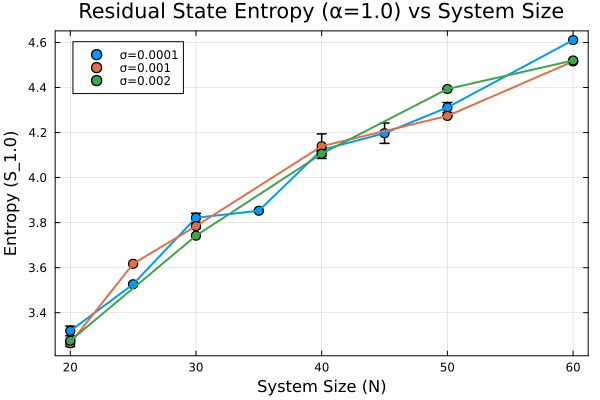

In [21]:
# calculate renyi entropy alpha=1.0 for a few sigmas

Ns = [20, 25, 30, 35, 40, 45, 50, 60]
sigmas = [0.0001, 0.001, 0.002]
alpha_renyi = 1.0

p_ent = plot(title="Residual State Entropy (α=$alpha_renyi) vs System Size",
             xlabel="System Size (N)",
             ylabel="Entropy (S_$(alpha_renyi))",
             legend=:topleft,
             grid=true,
             framestyle=:box)

for (idx, σ) in enumerate(sigmas)
    avg_S = Float64[]
    err_S = Float64[]
    valid_Ns = Int[]

    for N in Ns
        c_mpss, d_mpss = fetch_states(N, σ, sysparams; max=3, type=:all)
        num_instances = min(length(c_mpss), length(d_mpss))
        if num_instances == 0
            continue
        end

        S_instances = Float64[]

        for j in 1:num_instances
            p_cln, p_dis = c_mpss[j], d_mpss[j]
            p_res = get_residual_state(p_dis, p_cln; normalize=true)
            s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
            S = calculate_renyi_entropy(s_res, alpha_renyi)
            push!(S_instances, S)
        end

        if !isempty(S_instances)
            push!(valid_Ns, N)
            push!(avg_S, mean(S_instances))
            if length(S_instances) > 1
                push!(err_S, std(S_instances) / sqrt(length(S_instances)))
            else
                push!(err_S, 0.0)
            end
        end
    end

    if !isempty(valid_Ns)
        scatter!(p_ent, valid_Ns, avg_S, yerror=err_S,
                 label="σ=$(σ)", color=idx, markersize=5, markerstrokewidth=1.5)
        plot!(p_ent, valid_Ns, avg_S, color=idx, lw=2, label=false)
    end
end

display(p_ent)

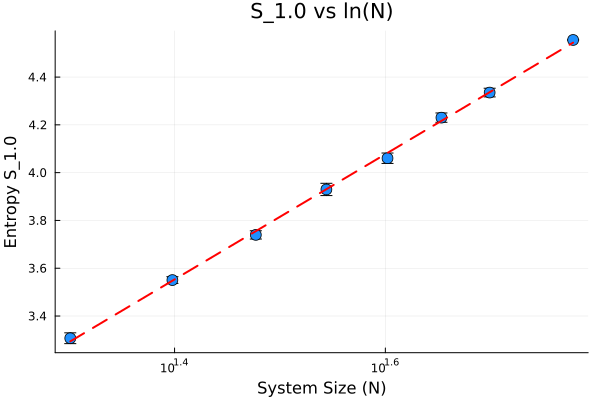

In [22]:
# check if the renyi-entropy for alpha=1.0 fits on a log scale

alpha_renyi = 1.0
Ns = [20, 25, 30, 35, 40, 45, 50, 60]
σ_test = 0.0019

avg_S = Float64[]
err_S = Float64[]
valid_Ns = Int[]

for N in Ns
    c_mpss, d_mpss = fetch_states(N, σ_test, sysparams; max=3, type=:all)
    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0 continue end

    S_instances = Float64[]
    for j in 1:num_instances
        p_res = get_residual_state(d_mpss[j], c_mpss[j]; normalize=true)
        s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
        push!(S_instances, calculate_renyi_entropy(s_res, alpha_renyi))
    end

    push!(valid_Ns, N)
    push!(avg_S, mean(S_instances))
    push!(err_S, length(S_instances) > 1 ? std(S_instances)/sqrt(length(S_instances)) : 0.0)
end

p_semilog = scatter(valid_Ns, avg_S, yerror=err_S,
                    title="S_$(alpha_renyi) vs ln(N)",
                    xlabel="System Size (N)",
                    ylabel="Entropy S_$(alpha_renyi)",
                    xaxis=:log10,
                    legend=false, color=:dodgerblue, grid=true, markersize=6)

coeffs_log = hcat(log.(valid_Ns), ones(length(valid_Ns))) \ avg_S
A_log, B_log = coeffs_log[1], coeffs_log[2]
N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
plot!(p_semilog, N_smooth, A_log .* log.(N_smooth) .+ B_log, color=:red, lw=2, linestyle=:dash)

display(p_semilog)

For $\alpha=1.0$ we seem to be very logarithmic. This puts us in the 'undetermined' region (Schuh et al.). We can try some different $\alpha$ values.

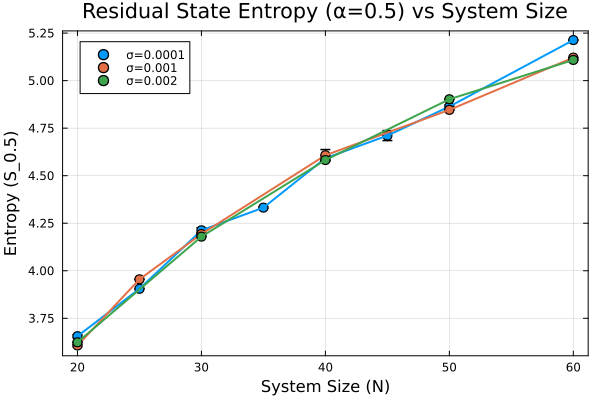

In [23]:
# calculate renyi entropy alpha=0.5 for a few sigmas

Ns = [20, 25, 30, 35, 40, 45, 50, 60]
sigmas = [0.0001, 0.001, 0.002]
alpha_renyi = 0.5

p_ent = plot(title="Residual State Entropy (α=$alpha_renyi) vs System Size",
             xlabel="System Size (N)",
             ylabel="Entropy (S_$(alpha_renyi))",
             legend=:topleft,
             grid=true,
             framestyle=:box)

for (idx, σ) in enumerate(sigmas)
    avg_S = Float64[]
    err_S = Float64[]
    valid_Ns = Int[]

    for N in Ns
        c_mpss, d_mpss = fetch_states(N, σ, sysparams; max=3, type=:all)
        num_instances = min(length(c_mpss), length(d_mpss))
        if num_instances == 0
            continue
        end

        S_instances = Float64[]

        for j in 1:num_instances
            p_cln, p_dis = c_mpss[j], d_mpss[j]
            p_res = get_residual_state(p_dis, p_cln; normalize=true)
            s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
            S = calculate_renyi_entropy(s_res, alpha_renyi)
            push!(S_instances, S)
        end

        if !isempty(S_instances)
            push!(valid_Ns, N)
            push!(avg_S, mean(S_instances))
            if length(S_instances) > 1
                push!(err_S, std(S_instances) / sqrt(length(S_instances)))
            else
                push!(err_S, 0.0)
            end
        end
    end

    if !isempty(valid_Ns)
        scatter!(p_ent, valid_Ns, avg_S, yerror=err_S,
                 label="σ=$(σ)", color=idx, markersize=5, markerstrokewidth=1.5)
        plot!(p_ent, valid_Ns, avg_S, color=idx, lw=2, label=false)
    end
end

display(p_ent)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:36


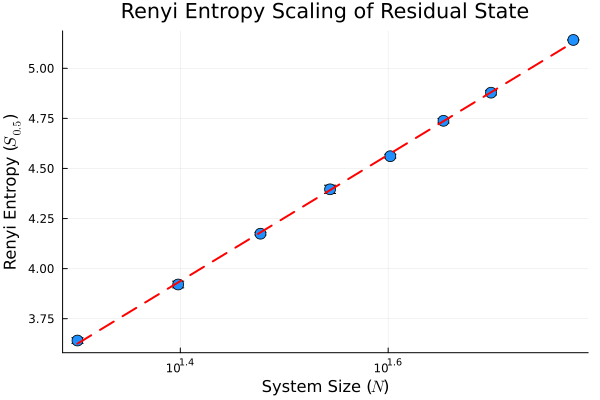

In [39]:
# check if the renyi-entropy for alpha=0.5 fits on a log scale

Ns = 20:5:80

alpha_renyi = 0.5
σ_test = 0.0019

avg_S = Float64[]
err_S = Float64[]
valid_Ns = Int[]

prog = Progress(length(Ns))

for N in Ns
    c_mpss, d_mpss = fetch_states(N, σ_test, sysparams; max=3, type=:all)
    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0
        next!(prog)
        continue
    end

    S_instances = Float64[]
    for j in 1:num_instances
        p_res = get_residual_state(d_mpss[j], c_mpss[j]; normalize=true)
        s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
        push!(S_instances, calculate_renyi_entropy(s_res, alpha_renyi))
    end

    push!(valid_Ns, N)
    push!(avg_S, mean(S_instances))
    push!(err_S, length(S_instances) > 1 ? std(S_instances)/sqrt(length(S_instances)) : 0.0)
    next!(prog)
end

p_semilog = scatter(valid_Ns, avg_S, yerror=err_S,
                    title="Renyi Entropy Scaling of Residual State",
                    xlabel=L"System Size ($N$)",
                    ylabel=L"Renyi Entropy ($S_{0.5}$)",
                    xaxis=:log10,
                    legend=false, color=:dodgerblue, grid=true, markersize=6)

coeffs_log = hcat(log.(valid_Ns), ones(length(valid_Ns))) \ avg_S
A_log, B_log = coeffs_log[1], coeffs_log[2]
N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
plot!(p_semilog, N_smooth, A_log .* log.(N_smooth) .+ B_log, color=:red, lw=2, linestyle=:dash)

display(p_semilog)

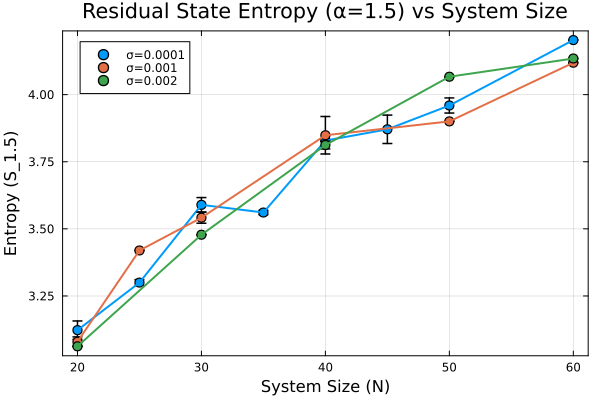

In [25]:
# calculate renyi entropy alpha=1.5 for a few sigmas

Ns = [20, 25, 30, 35, 40, 45, 50, 60]
sigmas = [0.0001, 0.001, 0.002]
alpha_renyi = 1.5

p_ent = plot(title="Residual State Entropy (α=$alpha_renyi) vs System Size",
             xlabel="System Size (N)",
             ylabel="Entropy (S_$(alpha_renyi))",
             legend=:topleft,
             grid=true,
             framestyle=:box)

for (idx, σ) in enumerate(sigmas)
    avg_S = Float64[]
    err_S = Float64[]
    valid_Ns = Int[]

    for N in Ns
        c_mpss, d_mpss = fetch_states(N, σ, sysparams; max=3, type=:all)
        num_instances = min(length(c_mpss), length(d_mpss))
        if num_instances == 0
            continue
        end

        S_instances = Float64[]

        for j in 1:num_instances
            p_cln, p_dis = c_mpss[j], d_mpss[j]
            p_res = get_residual_state(p_dis, p_cln; normalize=true)
            s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
            S = calculate_renyi_entropy(s_res, alpha_renyi)
            push!(S_instances, S)
        end

        if !isempty(S_instances)
            push!(valid_Ns, N)
            push!(avg_S, mean(S_instances))
            if length(S_instances) > 1
                push!(err_S, std(S_instances) / sqrt(length(S_instances)))
            else
                push!(err_S, 0.0)
            end
        end
    end

    if !isempty(valid_Ns)
        scatter!(p_ent, valid_Ns, avg_S, yerror=err_S,
                 label="σ=$(σ)", color=idx, markersize=5, markerstrokewidth=1.5)
        plot!(p_ent, valid_Ns, avg_S, color=idx, lw=2, label=false)
    end
end

display(p_ent)

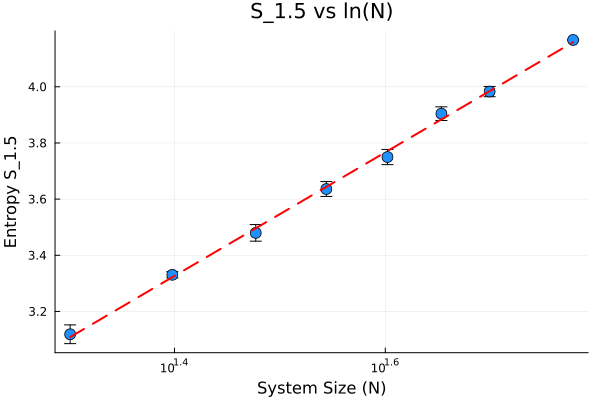

In [26]:
# check if the renyi-entropy for alpha=1.5 fits on a log scale

alpha_renyi = 1.5
Ns = [20, 25, 30, 35, 40, 45, 50, 60]
σ_test = 0.0019

avg_S = Float64[]
err_S = Float64[]
valid_Ns = Int[]

for N in Ns
    c_mpss, d_mpss = fetch_states(N, σ_test, sysparams; max=3, type=:all)
    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0 continue end

    S_instances = Float64[]
    for j in 1:num_instances
        p_res = get_residual_state(d_mpss[j], c_mpss[j]; normalize=true)
        s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
        push!(S_instances, calculate_renyi_entropy(s_res, alpha_renyi))
    end

    push!(valid_Ns, N)
    push!(avg_S, mean(S_instances))
    push!(err_S, length(S_instances) > 1 ? std(S_instances)/sqrt(length(S_instances)) : 0.0)
end

p_semilog = scatter(valid_Ns, avg_S, yerror=err_S,
                    title="S_$(alpha_renyi) vs ln(N)",
                    xlabel="System Size (N)",
                    ylabel="Entropy S_$(alpha_renyi)",
                    xaxis=:log10,
                    legend=false, color=:dodgerblue, grid=true, markersize=6)

coeffs_log = hcat(log.(valid_Ns), ones(length(valid_Ns))) \ avg_S
A_log, B_log = coeffs_log[1], coeffs_log[2]
N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
plot!(p_semilog, N_smooth, A_log .* log.(N_smooth) .+ B_log, color=:red, lw=2, linestyle=:dash)

display(p_semilog)

They all appear to be pretty logarithmic. This is important. The $\alpha < 1$ logarithmic scaling implies that the state is indeed simulable according to Schuh et al. 

In [ ]:
# check if the renyi-entropy for alpha=0.5 fits on a log scale

Ns = 20:5:80

alpha_renyi = 0.5
σ_test = 0.0019

avg_S = Float64[]
err_S = Float64[]
valid_Ns = Int[]

prog = Progress(length(Ns))

for N in Ns
    c_mpss, d_mpss = fetch_states(N, σ_test, sysparams; max=3, type=:all)
    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0
        next!(prog)
        continue
    end

    S_instances = Float64[]
    for j in 1:num_instances
        p_res = get_residual_state(d_mpss[j], c_mpss[j]; normalize=true)
        s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
        push!(S_instances, calculate_renyi_entropy(s_res, alpha_renyi))
    end

    push!(valid_Ns, N)
    push!(avg_S, mean(S_instances))
    push!(err_S, length(S_instances) > 1 ? std(S_instances)/sqrt(length(S_instances)) : 0.0)
    next!(prog)
end

p_semilog = scatter(valid_Ns, avg_S, yerror=err_S,
                    title="Residual State Entropy Scaling with System Size (α=0.5)",
                    xlabel="System Size (N)",
                    ylabel="Renyi Entropy (S)",
                    xaxis=:log10,
                    legend=false, color=:dodgerblue, grid=true, markersize=6)

coeffs_log = hcat(log.(valid_Ns), ones(length(valid_Ns))) \ avg_S
A_log, B_log = coeffs_log[1], coeffs_log[2]
N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
plot!(p_semilog, N_smooth, A_log .* log.(N_smooth) .+ B_log, color=:red, lw=2, linestyle=:dash)

display(p_semilog)

┌ Warning: File does not exist: /Users/jamesneville-rolfe/dev/uni/msciproject/programs/residual_states/../../data/storage/perturb_sigma_5.0e-7_Δ=-1.00e+00_J=-1.00e+00_μ=1.00e+00_MAX_BOND_DIM=1000_NUM_SWEEPS=10_ACC=1.00e-16.hd5
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:499
┌ Warning: File does not exist: /Users/jamesneville-rolfe/dev/uni/msciproject/programs/residual_states/../../data/storage/perturb_sigma_5.0e-7_Δ=-1.00e+00_J=-1.00e+00_μ=1.00e+00_MAX_BOND_DIM=1000_NUM_SWEEPS=10_ACC=1.00e-16.hd5
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:499
┌ Warning: File does not exist: /Users/jamesneville-rolfe/dev/uni/msciproject/programs/residual_states/../../data/storage/perturb_sigma_5.0e-7_Δ=-1.00e+00_J=-1.00e+00_μ=1.00e+00_MAX_BOND_DIM=1000_NUM_SWEEPS=10_ACC=1.00e-16.hd5
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:499
┌ Warning: File does not exist: /Users/jamesneville-rolfe/dev/uni/mscipro

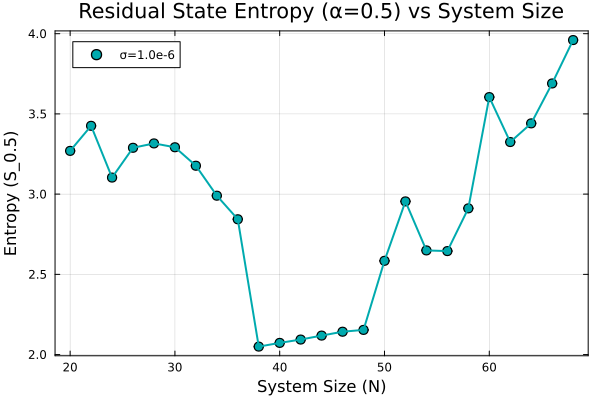

In [33]:
# calculate renyi entropy alpha=0.5 for a few sigmas

sysparmas = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 25,
                    "MAX_BOND_DIM" => 2000,
                    "ACC" => 1e-16
                )

Ns = 2:2:80
sigmas = [5e-7, 6e-7, 7e-7, 8e-7, 9e-7, 1e-6]


p_ent = plot(title="Residual State Entropy (α=$alpha_renyi) vs System Size",
             xlabel="System Size (N)",
             ylabel="Entropy (S_$(alpha_renyi))",
             legend=:topleft,
             grid=true,
             framestyle=:box)

for (idx, σ) in enumerate(sigmas)
    avg_S = Float64[]
    err_S = Float64[]
    valid_Ns = Int[]

    prog = Progress(length(Ns); desc="σ=$σ")
    for N in Ns
        c_mpss, d_mpss = fetch_states(N, σ, sysparams; max=3, type=:all)
        num_instances = min(length(c_mpss), length(d_mpss))
        if num_instances == 0
            next!(prog)
            continue
        end

        S_instances = Float64[]

        for j in 1:num_instances
            p_cln, p_dis = c_mpss[j], d_mpss[j]
            p_res = get_residual_state(p_dis, p_cln; normalize=true)
            s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
            S = calculate_renyi_entropy(s_res, alpha_renyi)
            push!(S_instances, S)
        end

        if !isempty(S_instances)
            push!(valid_Ns, N)
            push!(avg_S, mean(S_instances))
            if length(S_instances) > 1
                push!(err_S, std(S_instances) / sqrt(length(S_instances)))
            else
                push!(err_S, 0.0)
            end
        end
        next!(prog)
    end

    if !isempty(valid_Ns)
        scatter!(p_ent, valid_Ns, avg_S, yerror=err_S,
                 label="σ=$(σ)", color=idx, markersize=5, markerstrokewidth=1.5)
        plot!(p_ent, valid_Ns, avg_S, color=idx, lw=2, label=false)
    end
end

display(p_ent)

### Truncation Error

The truncation error of a state is given by $$\varepsilon (\chi) = \sum_{k>\chi} \lambda_k^2$$ We can then write a function to calculate the truncation error of a Schmidt spectrum as a function of $\chi$.

In [5]:
function truncation_error(schmidt_spectrum::Vector{Float64}, χ::Int64)::Float64
    if χ >= length(schmidt_spectrum)
        # if χ greater than the length of the spectrum, not truncation occurs
        return 0.0
    end
    truncated = schmidt_spectrum[(χ + 1):end]
    return sum(truncated)
end

truncation_error (generic function with 1 method)

We can then plot this truncation error as a function of $\chi$ for different system sizes.

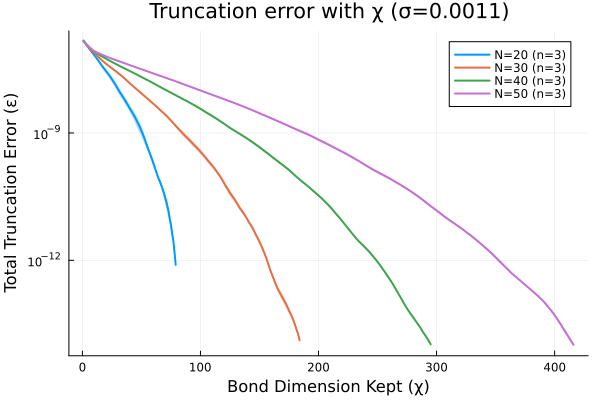

In [28]:
# plot truncation error as a function of χ for different N
Ns = [20, 30, 40, 50]
σ_fan = 0.0011

p3 = plot(title="Truncation error with χ (σ=$σ_fan)", yscale=:log10,
          xlabel="Bond Dimension Kept (χ)", ylabel="Total Truncation Error (ε)", legend=:topright, grid=true)

for (i, N) in enumerate(Ns)
    c_mpss, d_mpss = fetch_states(N, σ_fan, sysparams; max=3, type=:all)

    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0
        continue
    end

    all_s_res = Vector{Float64}[]
    cutoffs = Int[]

    for j in 1:num_instances
        p_cln, p_dis = c_mpss[j], d_mpss[j]
        p_res = get_residual_state(p_dis, p_cln; normalize=false)

        s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
        push!(all_s_res, s_res)
        push!(cutoffs, maxlinkdim(p_cln))
    end

    max_chi = maximum(length.(all_s_res))

    valid_k = Int[]
    avg_epsilons = Float64[]
    lower_errors = Float64[]
    upper_errors = Float64[]

    for k in 1:(max_chi - 1)
        eps_k = [truncation_error(s_res, k) for s_res in all_s_res]
        avg_eps = mean(eps_k)

        if avg_eps < 1e-14
            break
        end

        err_eps = num_instances > 1 ? std(eps_k) / sqrt(num_instances) : 0.0

        push!(valid_k, k)
        push!(avg_epsilons, avg_eps)

        push!(lower_errors, min(err_eps, avg_eps - 1e-15))
        push!(upper_errors, err_eps)
    end

    plot!(p3, valid_k, avg_epsilons,
          ribbon=(lower_errors, upper_errors), fillalpha=0.3,
          label="N=$N (n=$num_instances)", lw=2)
end

display(p3)

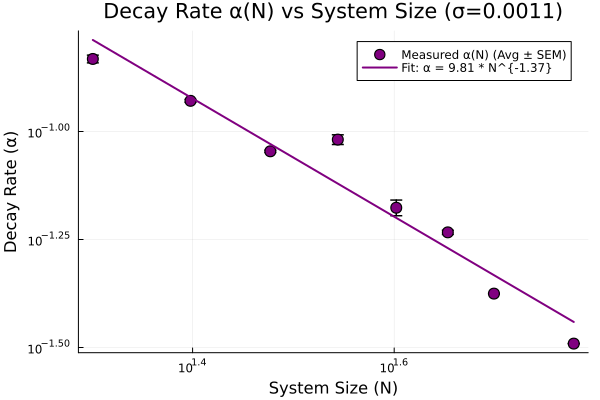

In [29]:
using Statistics

Ns = [20, 25, 30, 35, 40, 45, 50, 60]
σ_fan = 0.0011

valid_Ns = Int[]
avg_alphas = Float64[]
err_alphas = Float64[]

for N in Ns
    c_mpss, d_mpss = fetch_states(N, σ_fan, sysparams; max=3, type=:all)

    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0
        continue
    end

    instance_alphas = Float64[]

    for j in 1:num_instances
        p_cln, p_dis = c_mpss[j], d_mpss[j]
        p_res = get_residual_state(p_cln, p_dis; normalize=false)

        s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
        χ_c = maxlinkdim(p_cln)

        epsilons = [truncation_error(s_res, k) for k in 1:length(s_res)-1]

        valid_indices = findall(x -> x > 0.0, epsilons)

        if !isempty(valid_indices)
            idx_start = max(χ_c + 2, valid_indices[1])
            idx_end = valid_indices[end]

            if idx_start < idx_end
                eps_fit = epsilons[idx_start:idx_end]
                chi_fit = (idx_start:idx_end)

                coeffs = hcat(Float64.(chi_fit), ones(length(chi_fit))) \ log.(eps_fit)
                push!(instance_alphas, -coeffs[1])
            end
        end
    end

    if !isempty(instance_alphas)
        push!(valid_Ns, N)
        push!(avg_alphas, mean(instance_alphas))

        if length(instance_alphas) > 1
            push!(err_alphas, std(instance_alphas) / sqrt(length(instance_alphas)))
        else
            push!(err_alphas, 0.0)
        end
    end
end

coeffs_power = hcat(log.(valid_Ns), ones(length(valid_Ns))) \ log.(avg_alphas)
b_power = -coeffs_power[1]
A_power = exp(coeffs_power[2])

p4 = plot(title="Decay Rate α(N) vs System Size (σ=$σ_fan)",
          xlabel="System Size (N)", ylabel="Decay Rate (α)",
          yaxis=:log10, xaxis=:log10, grid=true)

scatter!(p4, valid_Ns, avg_alphas, yerror=err_alphas,
         label="Measured α(N) (Avg ± SEM)", color=:purple, markersize=6, markerstrokewidth=1.5)

N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
plot!(p4, N_smooth, A_power .* (N_smooth .^ -b_power),
      label="Fit: α = $(round(A_power, digits=2)) * N^{-$(round(b_power, digits=2))}",
      color=:purple, lw=2)

display(p4)

$$\chi_{\text{max}} \propto N^{1.37}$$

### For higher levels of disorder

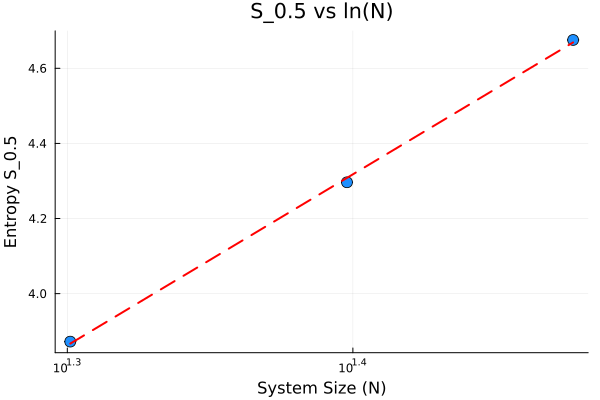

In [30]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 5000,
                    "ACC" => 1e-16
                )

# check if the renyi-entropy for alpha=0.5 fits on a log scale

alpha_renyi = 0.5
Ns = [20, 25, 30, 35, 40, 45, 50]
σ_test = 1.0

avg_S = Float64[]
err_S = Float64[]
valid_Ns = Int[]

for N in Ns
    c_mpss, d_mpss = fetch_states(N, σ_test, sysparams; max=3, type=:all)
    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0 continue end

    S_instances = Float64[]
    for j in 1:num_instances
        p_res = get_residual_state(d_mpss[j], c_mpss[j]; normalize=true)
        s_res = get_squared_sorted_schmidt_spectrum_from_mps(p_res)
        push!(S_instances, calculate_renyi_entropy(s_res, alpha_renyi))
    end

    push!(valid_Ns, N)
    push!(avg_S, mean(S_instances))
    push!(err_S, length(S_instances) > 1 ? std(S_instances)/sqrt(length(S_instances)) : 0.0)
end

p_semilog = scatter(valid_Ns, avg_S, yerror=err_S,
                    title="S_$(alpha_renyi) vs ln(N)",
                    xlabel="System Size (N)",
                    ylabel="Entropy S_$(alpha_renyi)",
                    xaxis=:log10,
                    legend=false, color=:dodgerblue, grid=true, markersize=6)

coeffs_log = hcat(log.(valid_Ns), ones(length(valid_Ns))) \ avg_S
A_log, B_log = coeffs_log[1], coeffs_log[2]
N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
plot!(p_semilog, N_smooth, A_log .* log.(N_smooth) .+ B_log, color=:red, lw=2, linestyle=:dash)

display(p_semilog)

### Bounding the Error

See Schuh

When we truncate to a finite bond dimension, we are forced to throw away the smallest probailites that are at index $>\chi$, the maximum bond dimension. After any bipartition cut at index $k$, the truncation error is $$\varepsilon_k(\chi)=\sum_{i=\chi+1}^{d^k} \lambda_i^{[k]}$$ where the $\lambda_i^{[k]}$ are the squared Schmidt coefficients for this bipartition. 

This tells us how much information we lose at a specific cut, but if we want the overall error on the state, we essentially have to do this for all possible cuts and sum up the errors. 

Schuh et al. (or a paper they reference) define this error as $$\text{max observable bound} = ||\ket{\psi} - \ket{\phi_\chi}|| \leq 2 \sum_{k=1}^{N-1} \varepsilon_k (\chi) $$ where $\ket{\psi}$ is the true state and $\ket{\phi_\chi}$ is the approximating state with bond dimension $\chi$.

This guarantees that the simulations error in measuring *any* physical property can never exceed twice the sum of the discarded probabilities over the entire spin system.

In [6]:
function state_error_bound(all_bonds_spectra::Vector{Vector{Float64}}, χ::Int)::Float64
    total_epsilon = 0.0

    for spectrum in all_bonds_spectra
        total_epsilon += truncation_error(spectrum, χ)
    end

    return 2.0 * total_epsilon
end

function get_all_schmidt_spectra_from_cuts(psi::MPS)::Vector{Vector{Float64}}
    N = length(psi)
    all_spectra = Vector{Vector{Float64}}()

    for b in 1:(N - 1)
        orthogonalize!(psi, b)

        if b == 1
            _, S, _ = svd(psi[b], siteind(psi, b))
        else
            _, S, _ = svd(psi[b], siteind(psi, b), linkind(psi, b-1))
        end

        schmidt_dim = dim(S, 1)
        schmidt_vals = Float64[]

        for n in 1:schmidt_dim
            push!(schmidt_vals, S[n, n])
        end

        squared_sorted = sort(schmidt_vals .^ 2, rev=true)
        push!(all_spectra, squared_sorted)
    end

    return all_spectra
end

get_all_schmidt_spectra_from_cuts (generic function with 1 method)

For the residual state:

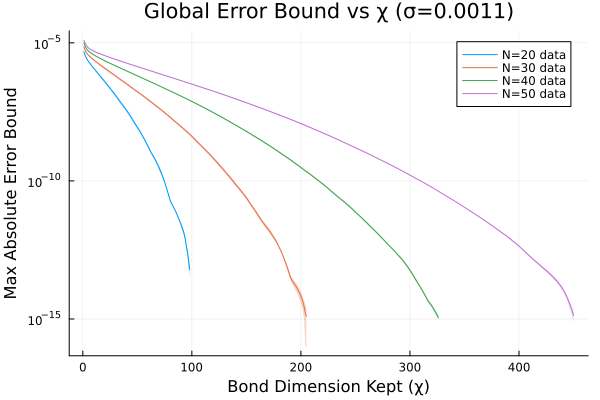

In [32]:
Ns = [20, 30, 40, 50]
σ_fan = 0.0011

p_err = plot(title="Global Error Bound vs χ (σ=$σ_fan)", yaxis=:log10,
          xlabel="Bond Dimension Kept (χ)", ylabel="Max Absolute Error Bound",
          legend=:topright, grid=true)

for (i, N) in enumerate(Ns)
    c_mpss, d_mpss = fetch_states(N, σ_fan, sysparams; max=3, type=:all)

    num_instances = min(length(c_mpss), length(d_mpss))
    if num_instances == 0
        continue
    end

    all_instances_spectra = Vector{Vector{Vector{Float64}}}()

    for j in 1:num_instances
        p_cln, p_dis = c_mpss[j], d_mpss[j]
        p_res = get_residual_state(p_dis, p_cln; normalize=false)

        spectra = get_all_schmidt_spectra_from_cuts(p_res)
        push!(all_instances_spectra, spectra)
    end

    max_chi = maximum([maximum([length(s) for s in inst]) for inst in all_instances_spectra])

    valid_k = Int[]
    avg_global_errors = Float64[]
    lower_errors = Float64[]
    upper_errors = Float64[]

    for k in 1:(max_chi - 1)
        errs_k = [state_error_bound(inst, k) for inst in all_instances_spectra]

        avg_err = mean(errs_k)

        if avg_err < 1e-15
            break
        end

        err_std = num_instances > 1 ? std(errs_k) / sqrt(num_instances) : 0.0

        push!(valid_k, k)
        push!(avg_global_errors, avg_err)
        push!(lower_errors, min(err_std, avg_err - 1e-16))
        push!(upper_errors, err_std)
    end

    plot!(p_err, valid_k, avg_global_errors,
          ribbon=(lower_errors, upper_errors), fillalpha=0.3,
          label="N=$N data")
end

display(p_err)

For all state types:

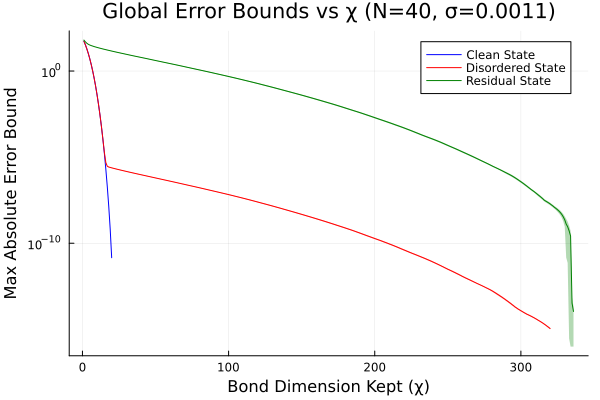

In [33]:

N = 40
σ_fan = 0.0011

p_err = plot(title="Global Error Bounds vs χ (N=$N, σ=$σ_fan)", yaxis=:log10,
          xlabel="Bond Dimension Kept (χ)", ylabel="Max Absolute Error Bound",
          legend=:topright, grid=true)

c_mpss, d_mpss = fetch_states(N, σ_fan, sysparams; max=3, type=:all)
num_instances = min(length(c_mpss), length(d_mpss))

if num_instances > 0
    # Arrays to store the all-bonds spectra for each state type
    cln_spectra_all = Vector{Vector{Vector{Float64}}}()
    dis_spectra_all = Vector{Vector{Vector{Float64}}}()
    res_spectra_all = Vector{Vector{Vector{Float64}}}()

    for j in 1:num_instances
        p_cln, p_dis = c_mpss[j], d_mpss[j]
        p_res = get_residual_state(p_dis, p_cln; normalize=true)

        push!(cln_spectra_all, get_all_schmidt_spectra_from_cuts(p_cln))
        push!(dis_spectra_all, get_all_schmidt_spectra_from_cuts(p_dis))
        push!(res_spectra_all, get_all_schmidt_spectra_from_cuts(p_res))
    end

    state_types = [
        ("Clean State", cln_spectra_all, :blue),
        ("Disordered State", dis_spectra_all, :red),
        ("Residual State", res_spectra_all, :green)
    ]

    for (label, instances_spectra, col) in state_types
        max_chi = maximum([maximum([length(s) for s in inst]) for inst in instances_spectra])

        valid_k = Int[]
        avg_global_errors = Float64[]
        lower_errors = Float64[]
        upper_errors = Float64[]

        for k in 1:(max_chi - 1)
            errs_k = [state_error_bound(inst, k) for inst in instances_spectra]

            avg_err = mean(errs_k)

            if avg_err < 1e-15
                break
            end

            err_std = num_instances > 1 ? std(errs_k) / sqrt(num_instances) : 0.0

            push!(valid_k, k)
            push!(avg_global_errors, avg_err)
            push!(lower_errors, min(err_std, avg_err - 1e-16))
            push!(upper_errors, err_std)
        end

        plot!(p_err, valid_k, avg_global_errors,
              ribbon=(lower_errors, upper_errors), fillalpha=0.3,
              label=label, color=col)
    end
else
    println("No instances found for N=$N, σ=$σ_fan.")
end

display(p_err)

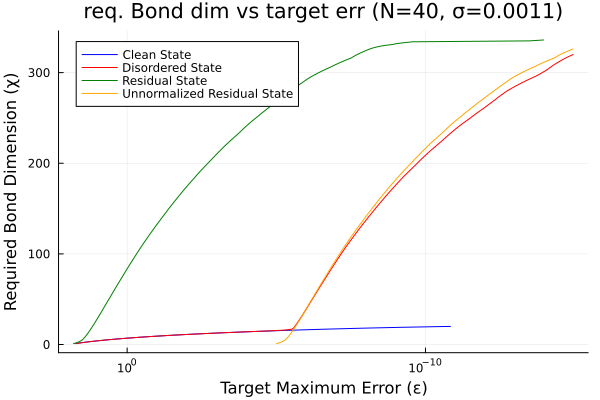

In [34]:
using Statistics
using Plots

N = 40
σ_fan = 0.0011

p_req = plot(title="req. Bond dim vs target err (N=$N, σ=$σ_fan)",
             xaxis=:log10, xflip=true,
             xlabel="Target Maximum Error (ε)", ylabel="Required Bond Dimension (χ)",
             legend=:topleft, grid=true)

c_mpss, d_mpss = fetch_states(N, σ_fan, sysparams; max=3, type=:all)
num_instances = min(length(c_mpss), length(d_mpss))

if num_instances > 0
    cln_spectra_all = Vector{Vector{Vector{Float64}}}()
    dis_spectra_all = Vector{Vector{Vector{Float64}}}()
    res_spectra_all = Vector{Vector{Vector{Float64}}}()
    un_res_spectra_all = Vector{Vector{Vector{Float64}}}()

    for j in 1:num_instances
        p_cln, p_dis = c_mpss[j], d_mpss[j]
        p_res = get_residual_state(p_dis, p_cln; normalize=true)
        un_p_res = get_residual_state(p_dis, p_cln; normalize=false)

        push!(cln_spectra_all, get_all_schmidt_spectra_from_cuts(p_cln))
        push!(dis_spectra_all, get_all_schmidt_spectra_from_cuts(p_dis))
        push!(res_spectra_all, get_all_schmidt_spectra_from_cuts(p_res))
        push!(un_res_spectra_all, get_all_schmidt_spectra_from_cuts(un_p_res))
    end

    state_types = [
        ("Clean State", cln_spectra_all, :blue),
        ("Disordered State", dis_spectra_all, :red),
        ("Residual State", res_spectra_all, :green),
        ("Unnormalized Residual State", un_res_spectra_all, :orange)

    ]

    for (label, instances_spectra, col) in state_types
        max_chi = maximum([maximum([length(s) for s in inst]) for inst in instances_spectra])

        valid_k = Int[]
        avg_global_errors = Float64[]

        for k in 1:(max_chi - 1)
            errs_k = [state_error_bound(inst, k) for inst in instances_spectra]

            avg_err = mean(errs_k)

            if avg_err < 1e-15
                break
            end

            push!(valid_k, k)
            push!(avg_global_errors, avg_err)
        end

        plot!(p_req, avg_global_errors, valid_k,
              label=label, color=col)
    end
else
    println("No instances found for N=$N, σ=$σ_fan.")
end

display(p_req)

epsilon N chi graph
sigma N chi graph

# 3D plots

We need a function to find the required bond dimension for a given error

In [8]:
function find_required_chi_for_given_state_error(all_bonds_spectra::Vector{Vector{Float64}}, target_error::Float64)::Int
    max_chi = maximum(length.(all_bonds_spectra))

    for χ in 1:(max_chi - 1)
        current_err = state_error_bound(all_bonds_spectra, χ)

        if current_err <= target_error
            return χ
        end
    end

    return max_chi
end

find_required_chi_for_given_state_error (generic function with 1 method)

### EPS

The full disordered state

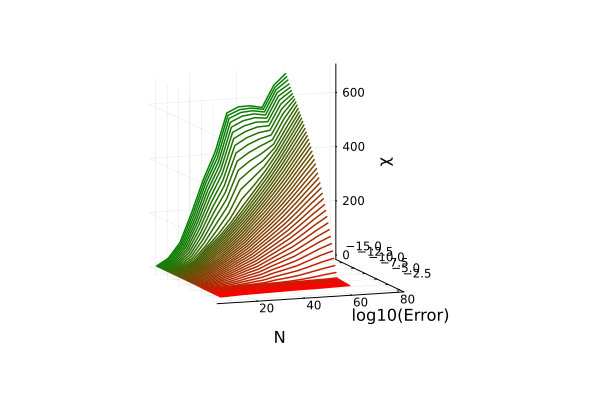

In [83]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 25,
                    "MAX_BOND_DIM" => 2000,
                    "ACC" => 1e-16
                )

gr()

# Define the range of system sizes and target errors
Ns = 5:5:80
target_errors = 10.0 .^ (-2:-0.25:-16)
σ_val = 0.002

Z = zeros(length(Ns), length(target_errors))

for (i, n) in enumerate(Ns)
    _, dis_mpss = fetch_states(n, σ_val, system_params; type=:all)
    spectra_all_instances = [get_all_schmidt_spectra_from_cuts(psi) for psi in dis_mpss]

    for (j, ε) in enumerate(target_errors)
        χs = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_all_instances]
        Z[i, j] = mean(χs)
    end
end

ε_logs = log10.(target_errors)
grad = cgrad([:green, :red])
n_lines = length(ε_logs)
idx_range = reverse(1:n_lines)

p2 = plot(
    xlabel = "N",
    ylabel = "log10(Error)",
    zlabel = "χ",
    camera = (-20, 10),
    yflip = true,
    zmirror = true,
    legend = false,
    grid = true,
    bg_inside = :white
)

for (k, j) in enumerate(idx_range)
    ε_log = ε_logs[j]

    line_color = grad[(k-1)/(n_lines-1)]

    floor_vec = fill(0.0, length(Ns))

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z[:, j],
          label = "ε = 10^$(round(ε_log))",
          lw = 1.5,
          color = line_color)
end

display(p2)

Just the clean state

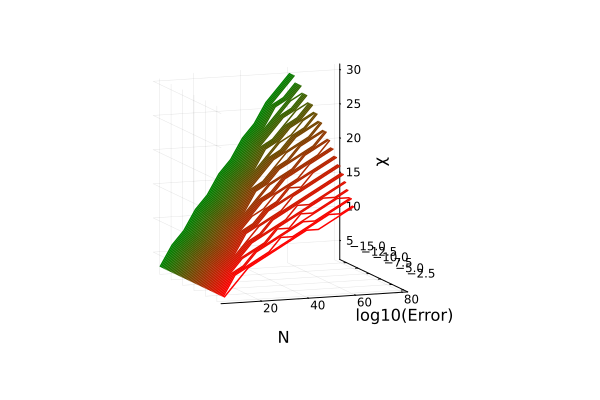

In [80]:
Z = zeros(length(Ns), length(target_errors))

for (i, n) in enumerate(Ns)
    cln_mpss, _ = fetch_states(n, σ_val, system_params; type=:all)
    spectra_all_instances = [get_all_schmidt_spectra_from_cuts(psi) for psi in cln_mpss]

    for (j, ε) in enumerate(target_errors)
        χs = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_all_instances]
        Z[i, j] = mean(χs)
    end
end

ε_logs = log10.(target_errors)
grad = cgrad([:green, :red])
n_lines = length(ε_logs)
idx_range = reverse(1:n_lines)

p2 = plot(
    xlabel = "N",
    ylabel = "log10(Error)",
    zlabel = "χ",
    camera = (-20, 10),
    yflip = true,
    zmirror = true,
    legend = false,
    grid = true,
    bg_inside = :white
)

for (k, j) in enumerate(idx_range)
    ε_log = ε_logs[j]

    line_color = grad[(k-1)/(n_lines-1)]

    floor_vec = fill(0.0, length(Ns))

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z[:, j],
          label = "ε = 10^$(round(ε_log))",
          lw = 1.5,
          color = line_color)
end

display(p2)

Just the residual state (unnormalised)

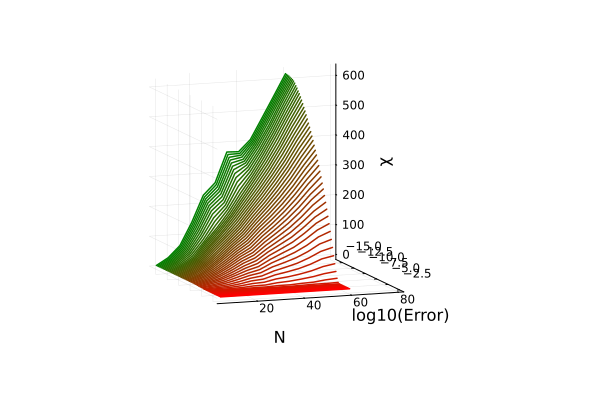

In [81]:
Z = zeros(length(Ns), length(target_errors))

for (i, n) in enumerate(Ns)
    cln_mpss, dis_mpss = fetch_states(n, σ_val, system_params; type=:all)
    res_mpss = [get_residual_state(dis, cln; normalize=false) for (cln, dis) in zip(cln_mpss, dis_mpss)]
    spectra_all_instances = [get_all_schmidt_spectra_from_cuts(psi) for psi in res_mpss]

    for (j, ε) in enumerate(target_errors)
        χs = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_all_instances]
        Z[i, j] = mean(χs)
    end
end

ε_logs = log10.(target_errors)
grad = cgrad([:green, :red])
n_lines = length(ε_logs)
idx_range = reverse(1:n_lines)

p2 = plot(
    xlabel = "N",
    ylabel = "log10(Error)",
    zlabel = "χ",
    camera = (-20, 10),
    yflip = true,
    zmirror = true,
    legend = false,
    grid = true,
    bg_inside = :white
)

for (k, j) in enumerate(idx_range)
    ε_log = ε_logs[j]

    line_color = grad[(k-1)/(n_lines-1)]

    floor_vec = fill(0.0, length(Ns))

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z[:, j],
          label = "ε = 10^$(round(ε_log))",
          lw = 1.5,
          color = line_color)
end

display(p2)

Residual state (normalised)

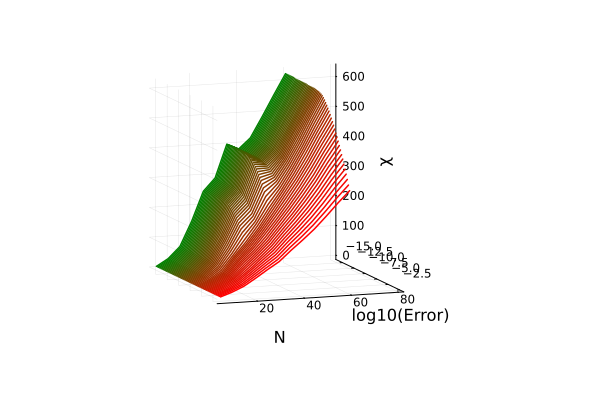

In [82]:
Z = zeros(length(Ns), length(target_errors))

for (i, n) in enumerate(Ns)
    cln_mpss, dis_mpss = fetch_states(n, σ_val, system_params; type=:all)
    res_mpss = [get_residual_state(dis, cln; normalize=true) for (cln, dis) in zip(cln_mpss, dis_mpss)]
    spectra_all_instances = [get_all_schmidt_spectra_from_cuts(psi) for psi in res_mpss]

    for (j, ε) in enumerate(target_errors)
        χs = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_all_instances]
        Z[i, j] = mean(χs)
    end
end

ε_logs = log10.(target_errors)
grad = cgrad([:green, :red])
n_lines = length(ε_logs)
idx_range = reverse(1:n_lines)

p2 = plot(
    xlabel = "N",
    ylabel = "log10(Error)",
    zlabel = "χ",
    camera = (-20, 10),
    yflip = true,
    zmirror = true,
    legend = false,
    grid = true,
    bg_inside = :white
)

for (k, j) in enumerate(idx_range)
    ε_log = ε_logs[j]

    line_color = grad[(k-1)/(n_lines-1)]

    floor_vec = fill(0.0, length(Ns))

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z[:, j],
          label = "ε = 10^$(round(ε_log))",
          lw = 1.5,
          color = line_color)
end

display(p2)

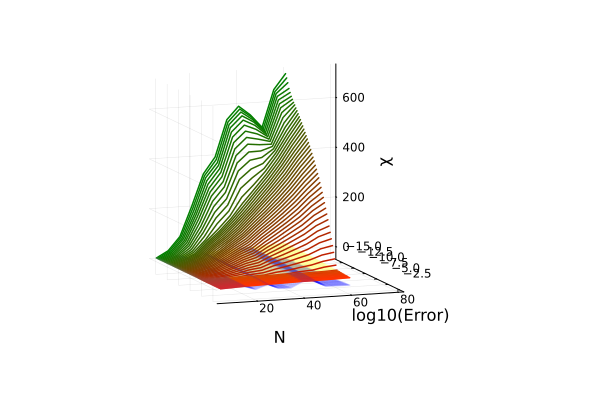

In [78]:
Z = zeros(length(Ns), length(target_errors))
Z_cln = zeros(length(Ns), length(target_errors))
Z_res = zeros(length(Ns), length(target_errors))

for (i, n) in enumerate(Ns)
    cln_mpss, dis_mpss = fetch_states(n, σ_val, system_params; type=:all)
    res_mpss = [get_residual_state(dis, cln; normalize=false) for (cln, dis) in zip(cln_mpss, dis_mpss)]

    ξ = mean([inner(cln, dis) for (cln, dis) in zip(cln_mpss, dis_mpss)])
    β = sqrt(1-ξ^2)

    spectra_dis = [get_all_schmidt_spectra_from_cuts(psi) for psi in dis_mpss]
    spectra_cln = [get_all_schmidt_spectra_from_cuts(psi) for psi in cln_mpss]
    spectra_res = [get_all_schmidt_spectra_from_cuts(psi) for psi in res_mpss]

    for (j, ε) in enumerate(target_errors)
        χs_dis = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_dis]
        χs_cln = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_cln]
        χs_res = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_res]
        Z[i, j] = mean(χs_dis)
        Z_cln[i, j] = mean(χs_cln)
        Z_res[i, j] = ξ * mean(χs_cln) + β * mean(χs_res)
    end
end

ε_logs = log10.(target_errors)
grad = cgrad([:green, :red])
n_lines = length(ε_logs)
idx_range = reverse(1:n_lines)

p2 = plot(
    xlabel = "N",
    ylabel = "log10(Error)",
    zlabel = "χ",
    camera = (-20, 10),
    yflip = true,
    zmirror = true,
    legend = false,
    grid = true,
    bg_inside = :white
)

for (k, j) in enumerate(idx_range)
    ε_log = ε_logs[j]

    line_color = grad[(k-1)/(n_lines-1)]

    floor_vec = fill(0.0, length(Ns))

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z[:, j],
          lw = 1.5,
          color = line_color)

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z_cln[:, j],
          lw = 1.5,
          color = :yellow, alpha=0.2)

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z_res[:, j],
          lw = 1.5,
          color = :blue, alpha=0.2)
end

display(p2)

### 10^-10

Full disordered state

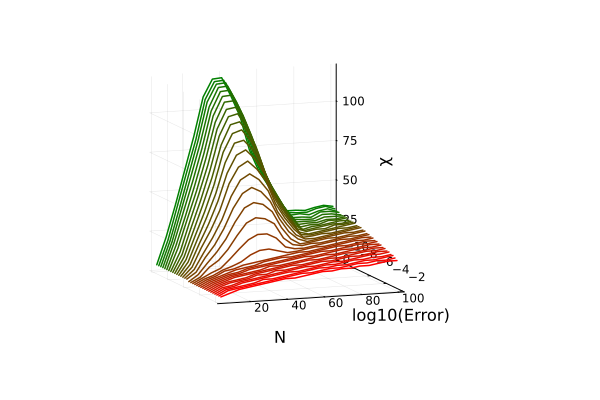

In [ ]:
Z = zeros(length(Ns), length(target_errors))

for (i, n) in enumerate(Ns)
    _, dis_mpss = fetch_states(n, σ_val, system_params; type=:all)
    spectra_all_instances = [get_all_schmidt_spectra_from_cuts(psi) for psi in dis_mpss]

    for (j, ε) in enumerate(target_errors)
        χs = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_all_instances]
        Z[i, j] = mean(χs)
    end
end

ε_logs = log10.(target_errors)
grad = cgrad([:green, :red])
n_lines = length(ε_logs)
idx_range = reverse(1:n_lines)

p2 = plot(
    xlabel = "N",
    ylabel = "log10(Error)",
    zlabel = "χ",
    camera = (-20, 10),
    yflip = true,
    zmirror = true,
    legend = false,
    grid = true,
    bg_inside = :white
)

for (k, j) in enumerate(idx_range)
    ε_log = ε_logs[j]

    line_color = grad[(k-1)/(n_lines-1)]

    floor_vec = fill(0.0, length(Ns))

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z[:, j],
          label = "ε = 10^$(round(ε_log))",
          lw = 1.5,
          color = line_color)
end

display(p2)

Just the clean state

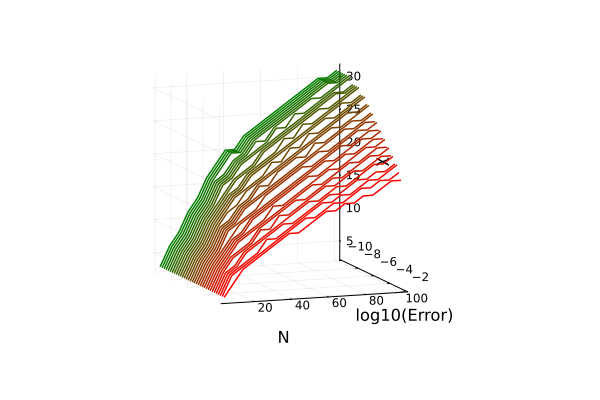

In [48]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 30,
                    "MAX_BOND_DIM" => 1001,
                    "ACC" => 1e-10
                )

gr()

Ns = sort(5:5:100)
target_errors = 10.0 .^ (-2:-0.25:-10)
σ_val = 0.002

Z = zeros(length(Ns), length(target_errors))

for (i, n) in enumerate(Ns)
    cln_mpss, _ = fetch_states(n, σ_val, system_params; type=:all)
    spectra_all_instances = [get_all_schmidt_spectra_from_cuts(psi) for psi in cln_mpss]

    for (j, ε) in enumerate(target_errors)
        χs = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_all_instances]
        Z[i, j] = mean(χs)
    end
end

ε_logs = log10.(target_errors)
grad = cgrad([:green, :red])
n_lines = length(ε_logs)
idx_range = reverse(1:n_lines)

p2 = plot(
    xlabel = "N",
    ylabel = "log10(Error)",
    zlabel = "χ",
    camera = (-20, 10),
    yflip = true,
    zmirror = true,
    legend = false,
    grid = true,
    bg_inside = :white
)

for (k, j) in enumerate(idx_range)
    ε_log = ε_logs[j]

    line_color = grad[(k-1)/(n_lines-1)]

    floor_vec = fill(0.0, length(Ns))

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z[:, j],
          label = "ε = 10^$(round(ε_log))",
          lw = 1.5,
          color = line_color)
end

display(p2)

Just the residual state (unnormalised)

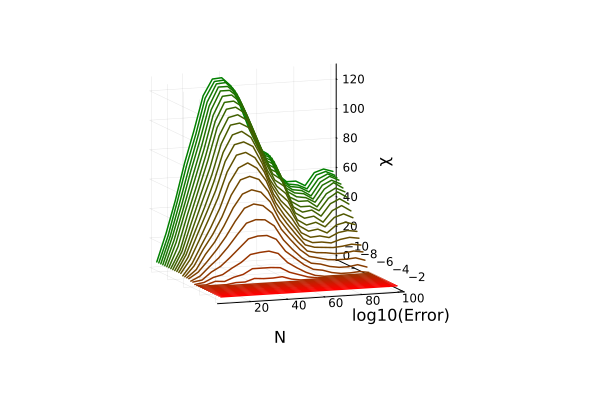

In [49]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 30,
                    "MAX_BOND_DIM" => 1001,
                    "ACC" => 1e-10
                )

gr()

Ns = sort(5:5:100)
target_errors = 10.0 .^ (-2:-0.25:-10)
σ_val = 0.002

Z = zeros(length(Ns), length(target_errors))

for (i, n) in enumerate(Ns)
    cln_mpss, dis_mpss = fetch_states(n, σ_val, system_params; type=:all)
    res_mpss = [get_residual_state(dis, cln; normalize=false) for (cln, dis) in zip(cln_mpss, dis_mpss)]
    spectra_all_instances = [get_all_schmidt_spectra_from_cuts(psi) for psi in res_mpss]

    for (j, ε) in enumerate(target_errors)
        χs = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_all_instances]
        Z[i, j] = mean(χs)
    end
end

ε_logs = log10.(target_errors)
grad = cgrad([:green, :red])
n_lines = length(ε_logs)
idx_range = reverse(1:n_lines)

p2 = plot(
    xlabel = "N",
    ylabel = "log10(Error)",
    zlabel = "χ",
    camera = (-20, 10),
    yflip = true,
    zmirror = true,
    legend = false,
    grid = true,
    bg_inside = :white
)

for (k, j) in enumerate(idx_range)
    ε_log = ε_logs[j]

    line_color = grad[(k-1)/(n_lines-1)]

    floor_vec = fill(0.0, length(Ns))

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z[:, j],
          label = "ε = 10^$(round(ε_log))",
          lw = 1.5,
          color = line_color)
end

display(p2)

Residual state (normalised)

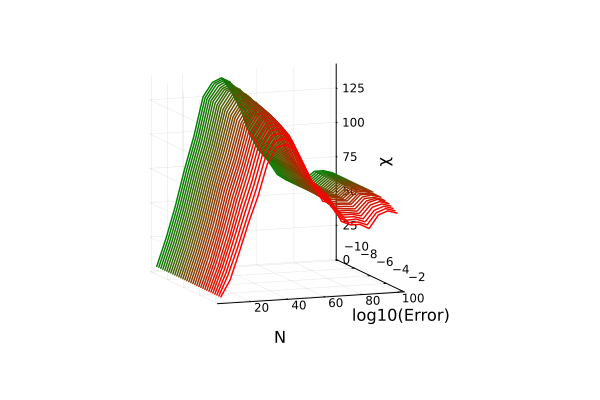

In [50]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 30,
                    "MAX_BOND_DIM" => 1001,
                    "ACC" => 1e-10
                )

gr()

Ns = sort(5:5:100)
target_errors = 10.0 .^ (-2:-0.25:-10)
σ_val = 0.002

Z = zeros(length(Ns), length(target_errors))

for (i, n) in enumerate(Ns)
    cln_mpss, dis_mpss = fetch_states(n, σ_val, system_params; type=:all)
    res_mpss = [get_residual_state(dis, cln; normalize=true) for (cln, dis) in zip(cln_mpss, dis_mpss)]
    spectra_all_instances = [get_all_schmidt_spectra_from_cuts(psi) for psi in res_mpss]

    for (j, ε) in enumerate(target_errors)
        χs = [find_required_chi_for_given_state_error(spec, ε) for spec in spectra_all_instances]
        Z[i, j] = mean(χs)
    end
end

ε_logs = log10.(target_errors)
grad = cgrad([:green, :red])
n_lines = length(ε_logs)
idx_range = reverse(1:n_lines)

p2 = plot(
    xlabel = "N",
    ylabel = "log10(Error)",
    zlabel = "χ",
    camera = (-20, 10),
    yflip = true,
    zmirror = true,
    legend = false,
    grid = true,
    bg_inside = :white
)

for (k, j) in enumerate(idx_range)
    ε_log = ε_logs[j]

    line_color = grad[(k-1)/(n_lines-1)]

    floor_vec = fill(0.0, length(Ns))

    plot!(p2, Ns, fill(ε_log, length(Ns)), Z[:, j],
          label = "ε = 10^$(round(ε_log))",
          lw = 1.5,
          color = line_color)
end

display(p2)

In [45]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 30,
                    "MAX_BOND_DIM" => 1001,
                    "ACC" => 1e-16
                )

valid_ns = []
cln_bd = []
dis_bd = []
res_bd = []

N_vals = 20:2:80
σ = 1e-6

for N in N_vals
    cln_all, dis_all = fetch_states(N, σ, system_params; type=:latest)
    if length(cln_all) > 0 && length(dis_all) > 0
        cln, dis = cln_all[1], dis_all[1]
        push!(valid_ns, N)
        res = get_residual_state(dis, cln)

        push!(cln_bd, maxlinkdim(cln))
        push!(dis_bd, maxlinkdim(dis))
        push!(res_bd, maxlinkdim(res))
    else
        continue
    end
end

p = plot(y_label="bond dim", x_label="n")
plot!(p, valid_ns, cln_bd, label="cln", markersize=1, marker=:circle)
plot!(p, valid_ns, dis_bd, label="dis", markersize=1, marker=:circle)
plot!(p, valid_ns, res_bd, label="res", markersize=1, marker=:circle)

display(p)

┌ Warning: Direct read into MPS failed for run 30 instance 1; attempting raw read for diagnostics.
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:568
┌ Info: Raw read type: Dict{String, Any}
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:575
┌ Info: Raw read keys: ["MPS[20]", "MPS[32]", "MPS[22]", "MPS[3]", "MPS[6]", "MPS[24]", "MPS[42]", "length", "MPS[36]", "MPS[39]", "MPS[48]", "MPS[18]", "MPS[15]", "MPS[45]", "MPS[1]", "MPS[26]", "MPS[17]", "MPS[44]", "MPS[12]", "MPS[28]", "MPS[27]", "MPS[21]", "MPS[7]", "MPS[5]", "MPS[38]", "MPS[29]", "MPS[10]", "MPS[16]", "MPS[19]", "MPS[35]", "MPS[47]", "MPS[8]", "MPS[23]", "MPS[40]", "MPS[13]", "MPS[41]", "MPS[9]", "MPS[30]", "MPS[25]", "MPS[33]", "MPS[4]", "MPS[11]", "MPS[14]", "MPS[37]", "MPS[43]", "llim", "MPS[2]", "MPS[31]", "MPS[46]", "rlim", "MPS[34]"]
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/data/helpers/saving.jl:577


InterruptException: InterruptException:

   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`
Progress:  94%|██████████████████████████████████████▌  |  ETA: 0:00:12

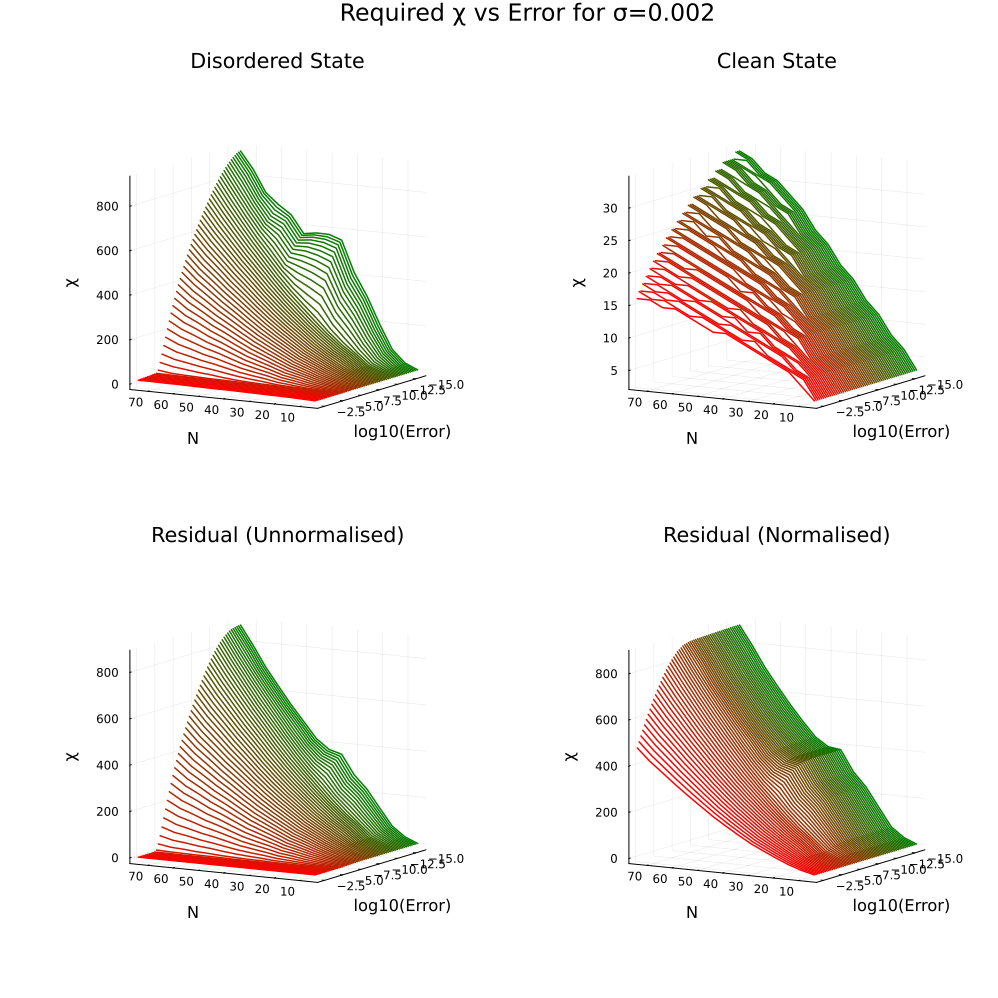

In [38]:
using Pkg; Pkg.add("ProgressMeter")
using ProgressMeter

function plot_chi_vs_error_grid(σ_val::Float64, system_params::Dict{String,Any};
                                Ns=5:5:80, target_errors=10.0 .^ (-2:-0.25:-16))

    gr()

    Z_dis = zeros(length(Ns), length(target_errors))
    Z_cln = zeros(length(Ns), length(target_errors))
    Z_res_unnorm = zeros(length(Ns), length(target_errors))
    Z_res_norm = zeros(length(Ns), length(target_errors))

    valid_mask = falses(length(Ns))

    prog = Progress(length(Ns))

    for (i, n) in enumerate(Ns)
        cln_mpss, dis_mpss = fetch_states(n, σ_val, system_params; type=:all)

        if isempty(cln_mpss) || isempty(dis_mpss)
            continue
        end

        valid_mask[i] = true

        spectra_cln = [get_all_schmidt_spectra_from_cuts(psi) for psi in cln_mpss]
        spectra_dis = [get_all_schmidt_spectra_from_cuts(psi) for psi in dis_mpss]

        res_mpss_unnorm = [get_residual_state(dis, cln; normalize=false)
                           for (cln, dis) in zip(cln_mpss, dis_mpss)]
        res_mpss_norm = [get_residual_state(dis, cln; normalize=true)
                         for (cln, dis) in zip(cln_mpss, dis_mpss)]

        spectra_res_unnorm = [get_all_schmidt_spectra_from_cuts(psi) for psi in res_mpss_unnorm]
        spectra_res_norm = [get_all_schmidt_spectra_from_cuts(psi) for psi in res_mpss_norm]

        for (j, ε) in enumerate(target_errors)
            Z_cln[i, j] = mean([find_required_chi_for_given_state_error(spec, ε)
                                for spec in spectra_cln])
            Z_dis[i, j] = mean([find_required_chi_for_given_state_error(spec, ε)
                                for spec in spectra_dis])
            Z_res_unnorm[i, j] = mean([find_required_chi_for_given_state_error(spec, ε)
                                       for spec in spectra_res_unnorm])
            Z_res_norm[i, j] = mean([find_required_chi_for_given_state_error(spec, ε)
                                     for spec in spectra_res_norm])
        end

        next!(prog)
    end

    valid_Ns = collect(Ns)[valid_mask]
    Z_dis_valid = Z_dis[valid_mask, :]
    Z_cln_valid = Z_cln[valid_mask, :]
    Z_res_unnorm_valid = Z_res_unnorm[valid_mask, :]
    Z_res_norm_valid = Z_res_norm[valid_mask, :]

    ε_logs = log10.(target_errors)
    grad = cgrad([:green, :red])
    n_lines = length(ε_logs)
    idx_range = reverse(1:n_lines)

    function create_subplot(Z::Matrix{Float64}, title::String)
        p = plot(
            xlabel = "N",
            ylabel = "log10(Error)",
            zlabel = "χ",
            title = title,
            camera = (30, 10),
            legend = false,
            grid = true,
            xflip=true,
            yflip=true,
            bg_inside = :white
        )

        for (k, j) in enumerate(idx_range)
            ε_log = ε_logs[j]
            line_color = grad[(k-1)/(n_lines-1)]

            plot!(p, valid_Ns, fill(ε_log, length(valid_Ns)), Z[:, j],
                lw = 1.5,
                color = line_color)
    end

    return p
end

    p1 = create_subplot(Z_dis_valid, "Disordered State")
    p2 = create_subplot(Z_cln_valid, "Clean State")
    p3 = create_subplot(Z_res_unnorm_valid, "Residual (Unnormalised)")
    p4 = create_subplot(Z_res_norm_valid, "Residual (Normalised)")

    p_grid = plot(p1, p2, p3, p4,
                  layout = (2, 2),
                  size = (1000, 1000),
                  plot_title = "Required χ vs Error for σ=$σ_val")

    return p_grid
end

system_params = Dict{String,Any}(
    "J" => -1.0,
    "Δ" => -1.0,
    "μ" => 1.0,
    "NUM_SWEEPS" => 25,
    "MAX_BOND_DIM" => 2000,
    "ACC" => 1e-16
)

p_combined = plot_chi_vs_error_grid(0.002, system_params)
display(p_combined)